# Data Exploration for Kaggle Housing Price Prediction

Exploratory analysis of the Ames Housing dataset for the [Kaggle Housing Prices Competition for Kaggle Learn Users](https://www.kaggle.com/competitions/home-data-for-ml-course). The dataset contains 1,460 residential home sales in Ames, Iowa with 79 features covering the physical attributes, quality ratings, and sale conditions of each property.

This notebook covers:
- **Missing data**: identifying which columns are missing and how to impute them
- **Feature distributions**: examining the target variable and its relationship with correlated columns
- **Normalisation**: investigating log transforms to linearize skewed relationships
- **Outlier identification**: using a residual-based OLS approach to flag anomalous transactions

Findings here directly inform the preprocessing pipeline and feature engineering used in the model notebooks in this repository.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

from pandas.api.types import CategoricalDtype

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# set global theme and disable frames
sns.set_theme(style = 'white',
              rc={'legend.frameon': False},
              )
sns.set_style('ticks', {'xtick.major.size' : 8,
                        'ytick.major.size' : 8,
                        'xtick.bottom'     : True,
                        'ytick.left'       : True,
                        })

In [2]:
# load the Kaggle train dataset
path_train = './input/train.csv.gz'
train      = pd.read_csv(path_train, compression='gzip', index_col='Id')

print(f'Shape of train_full dataset: {train.shape}')

Shape of train_full dataset: (1460, 80)


## Address Missing Data

Several columns have high rates of missing values. In most cases the missing value is meaningful. For instance, `FireplaceQu` is missing when there is no fireplace, `GarageType` when there is no garage. These can be filled with a `'NA'` rather than a statistical imputation. A few columns require more careful handling:

- **`LotFrontage`**: no clear definition for a missing value so imputed using a transformation of `LotArea`
- **`GarageYrBlt`**: houses without a garage are missing so can be imputed with `YearBuilt`
- **`MasVnrArea`**: always missing alongside `MasVnrType = NA`. Imputed with 0
- **`Electrical`**: imputed with the mode

In [3]:
# look for columns with a lot of missing data
missing_count = train.isnull().sum().sort_values(ascending=False)
missing_pct   = ((train.isnull().sum() / train.isnull().count()).sort_values(ascending=False) * 100).astype(int).astype(str) + '%'
missing_data  = pd.concat([missing_count, missing_pct], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,1453,99%
MiscFeature,1406,96%
Alley,1369,93%
Fence,1179,80%
MasVnrType,872,59%
FireplaceQu,690,47%
LotFrontage,259,17%
GarageQual,81,5%
GarageType,81,5%
GarageFinish,81,5%


In [4]:
# some columns here are nan for no feature so we can encode that instead of keeping values nan
train['PoolQC']        = train['PoolQC'].fillna('NA')
train['MiscFeature']   = train['MiscFeature'].fillna('NA')
train['Alley']         = train['Alley'].fillna('NA')
train['Fence']         = train['Fence'].fillna('NA')
train['MasVnrType']    = train['MasVnrType'].fillna('NA')
train['FireplaceQu']   = train['FireplaceQu'].fillna('NA')
train['GarageQual']    = train['GarageQual'].fillna('NA')
train['GarageFinish']  = train['GarageFinish'].fillna('NA')
train['GarageType']    = train['GarageType'].fillna('NA')
train['GarageCond']    = train['GarageCond'].fillna('NA')
train['BsmtFinType2']  = train['BsmtFinType2'].fillna('NA')
train['BsmtExposure']  = train['BsmtExposure'].fillna('NA')
train['BsmtCond']      = train['BsmtCond'].fillna('NA')
train['BsmtQual']      = train['BsmtQual'].fillna('NA')
train['BsmtFinType1']  = train['BsmtFinType1'].fillna('NA')

# no definition for nan in Electrical, only 1 missing so impute with mode
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

# check which columns are remaining
print(f'Remaining NaN values:\n{train.isnull().sum().sort_values(ascending=False).head()}')

Remaining NaN values:
LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
MSSubClass       0
Street           0
dtype: int64


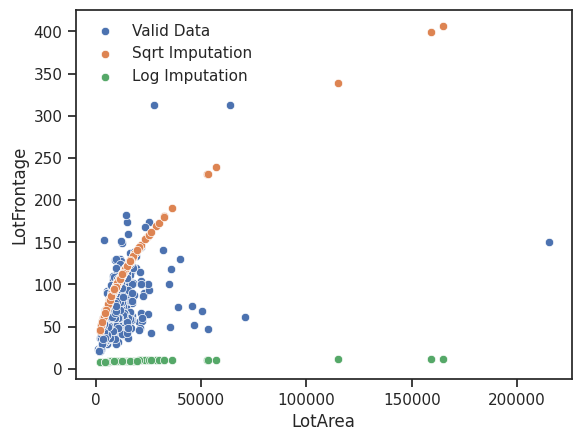

In [5]:
# figure out what to do with LotFrontage

# guess how to impute nans by filling with a transformation of LotArea
train['RootArea'] = np.sqrt(train['LotArea'])
train['LogArea']  = np.log(train['LotArea'])

fig, ax = plt.subplots()

sns.scatterplot(data=train, x='LotArea', y='LotFrontage', label='Valid Data')
sns.scatterplot(data=train[train['LotFrontage'].isna()], x='LotArea', y='RootArea', label='Sqrt Imputation')
sns.scatterplot(data=train[train['LotFrontage'].isna()], x='LotArea', y='LogArea', label='Log Imputation')

ax.legend()
plt.show()

# filling missing LotFrontage with the root of LotArea seems to agree
# reasonably well with the bulk of the data so it's probalby good
# enough for now
train['LotFrontage'] = train['LotFrontage'].fillna(train['RootArea'])

train = train.drop(columns=['RootArea', 'LogArea'])

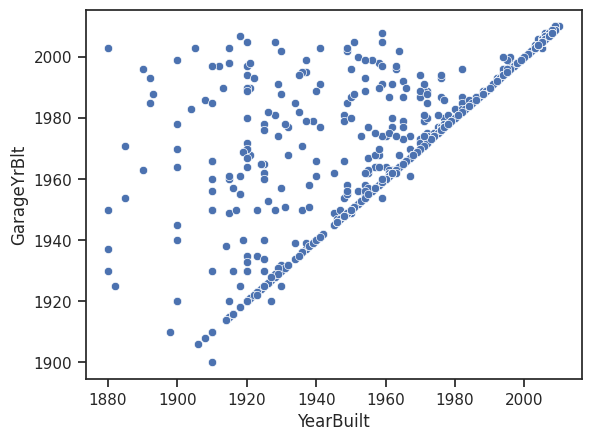

In [6]:
# figure out what to do wtih GarageYrBlt

sns.scatterplot(train, x='YearBuilt', y='GarageYrBlt')
plt.show()

# impute missing values with YearBuilt so missing values are roughly
# in line with rest of the data
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(train['YearBuilt'])

# looks like some data has the garage built before the house?
# just set these values to YearBuilt
train.loc[train['GarageYrBlt'] < train['YearBuilt'], 'GarageYrBlt'] = train['YearBuilt']

      MasVnrArea MasVnrType
Id                         
235          NaN         NA
530          NaN         NA
651          NaN         NA
937          NaN         NA
974          NaN         NA
978          NaN         NA
1244         NaN         NA
1279         NaN         NA


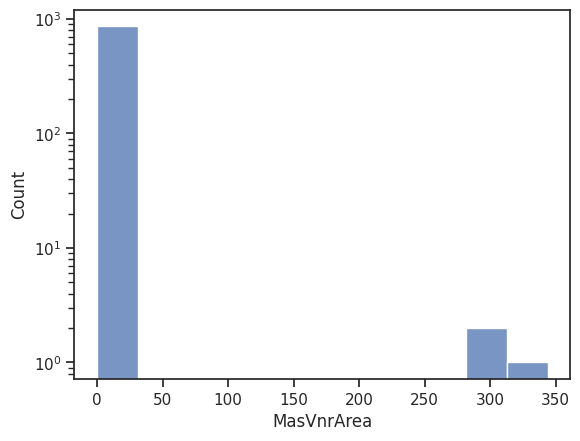

In [7]:
# figure out what to do with MasVnrArea

# MasVnrArea is only nan when MasVnrType is NA
print(train[train['MasVnrArea'].isna()][['MasVnrArea', 'MasVnrType']])

# most MasVnrArea values are 0 when MasVnrType is NA so just impute with 0
sns.histplot(train[train['MasVnrType'] == 'NA']['MasVnrArea'])
plt.yscale('log')
plt.show()

train['MasVnrArea'] = train['MasVnrArea'].fillna(0)

In [8]:
# confirm there is no more missing data
print(f'Remaining NaN values:\n{train.isnull().sum().sort_values(ascending=False).head()}')

Remaining NaN values:
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
Street         0
dtype: int64


## Feature Distributions and Correlations

Examine the distribution of `SalePrice` and its relationship to the most correlated numeric features.

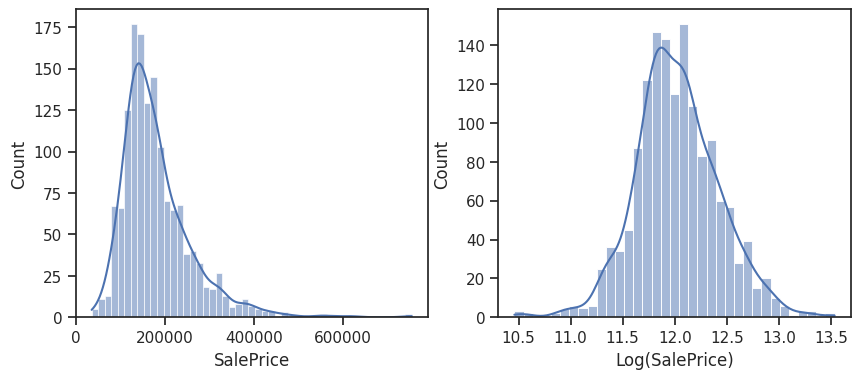

In [9]:
# SalePrice has a positive skew, looks more normal after log scaling

fig, axs = plt.subplots(figsize=(10, 4), ncols=2)

sns.histplot(train['SalePrice'], kde=True, ax=axs[0])

sns.histplot(np.log(train['SalePrice']), kde=True, ax=axs[1])
axs[1].set_xlabel('Log(SalePrice)')

plt.show()

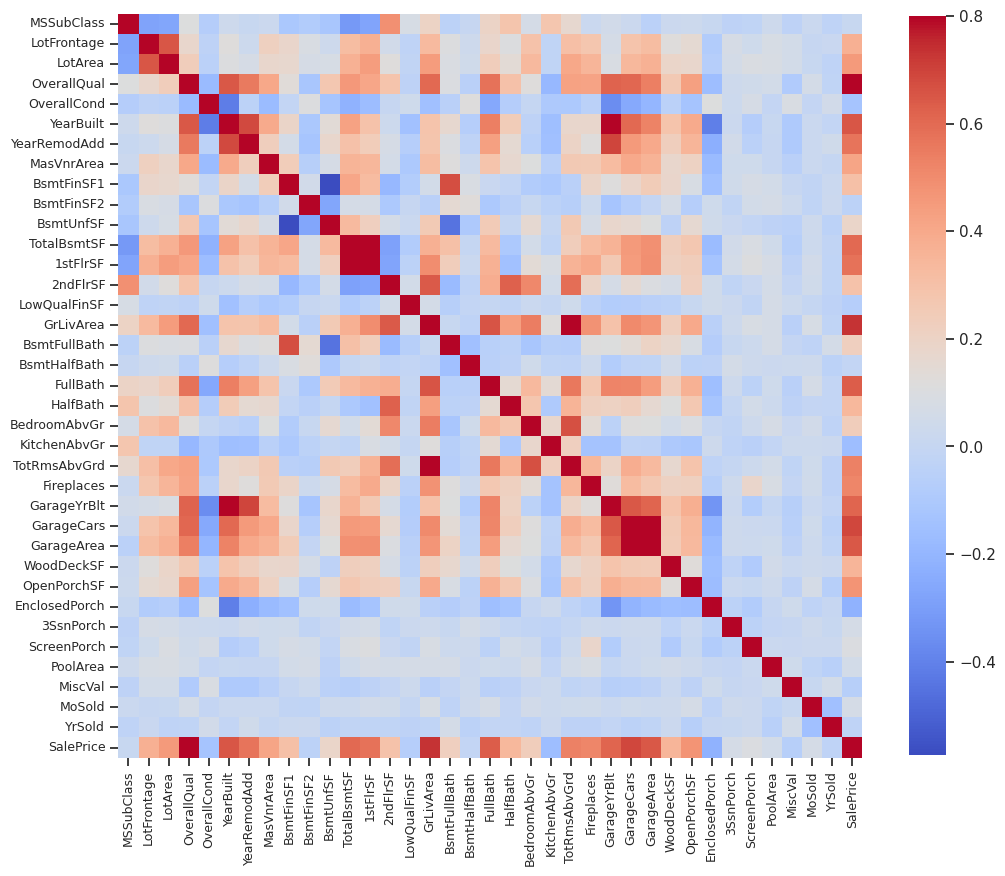

Highest absolute correlations with SalePrice:


OverallQual     0.809829
GrLivArea       0.731310
GarageCars      0.690711
YearBuilt       0.652682
GarageArea      0.649379
FullBath        0.635957
GarageYrBlt     0.613019
TotalBsmtSF     0.602725
1stFlrSF        0.575408
YearRemodAdd    0.571159
Name: SalePrice, dtype: float64

In [10]:
correlation_matrix = train.corr(method='spearman', numeric_only=True) # spearman to account for non-linearity

fig, ax = plt.subplots(figsize=(12,12))
sns.heatmap(correlation_matrix, vmax=0.8, square=True, cbar_kws={'shrink': 0.8}, cmap='coolwarm')

ax.tick_params(axis='both', labelsize=9)
plt.show()

# print columns most correlated with SalePrice
print('Highest absolute correlations with SalePrice:')
correlation_matrix['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)[:10]

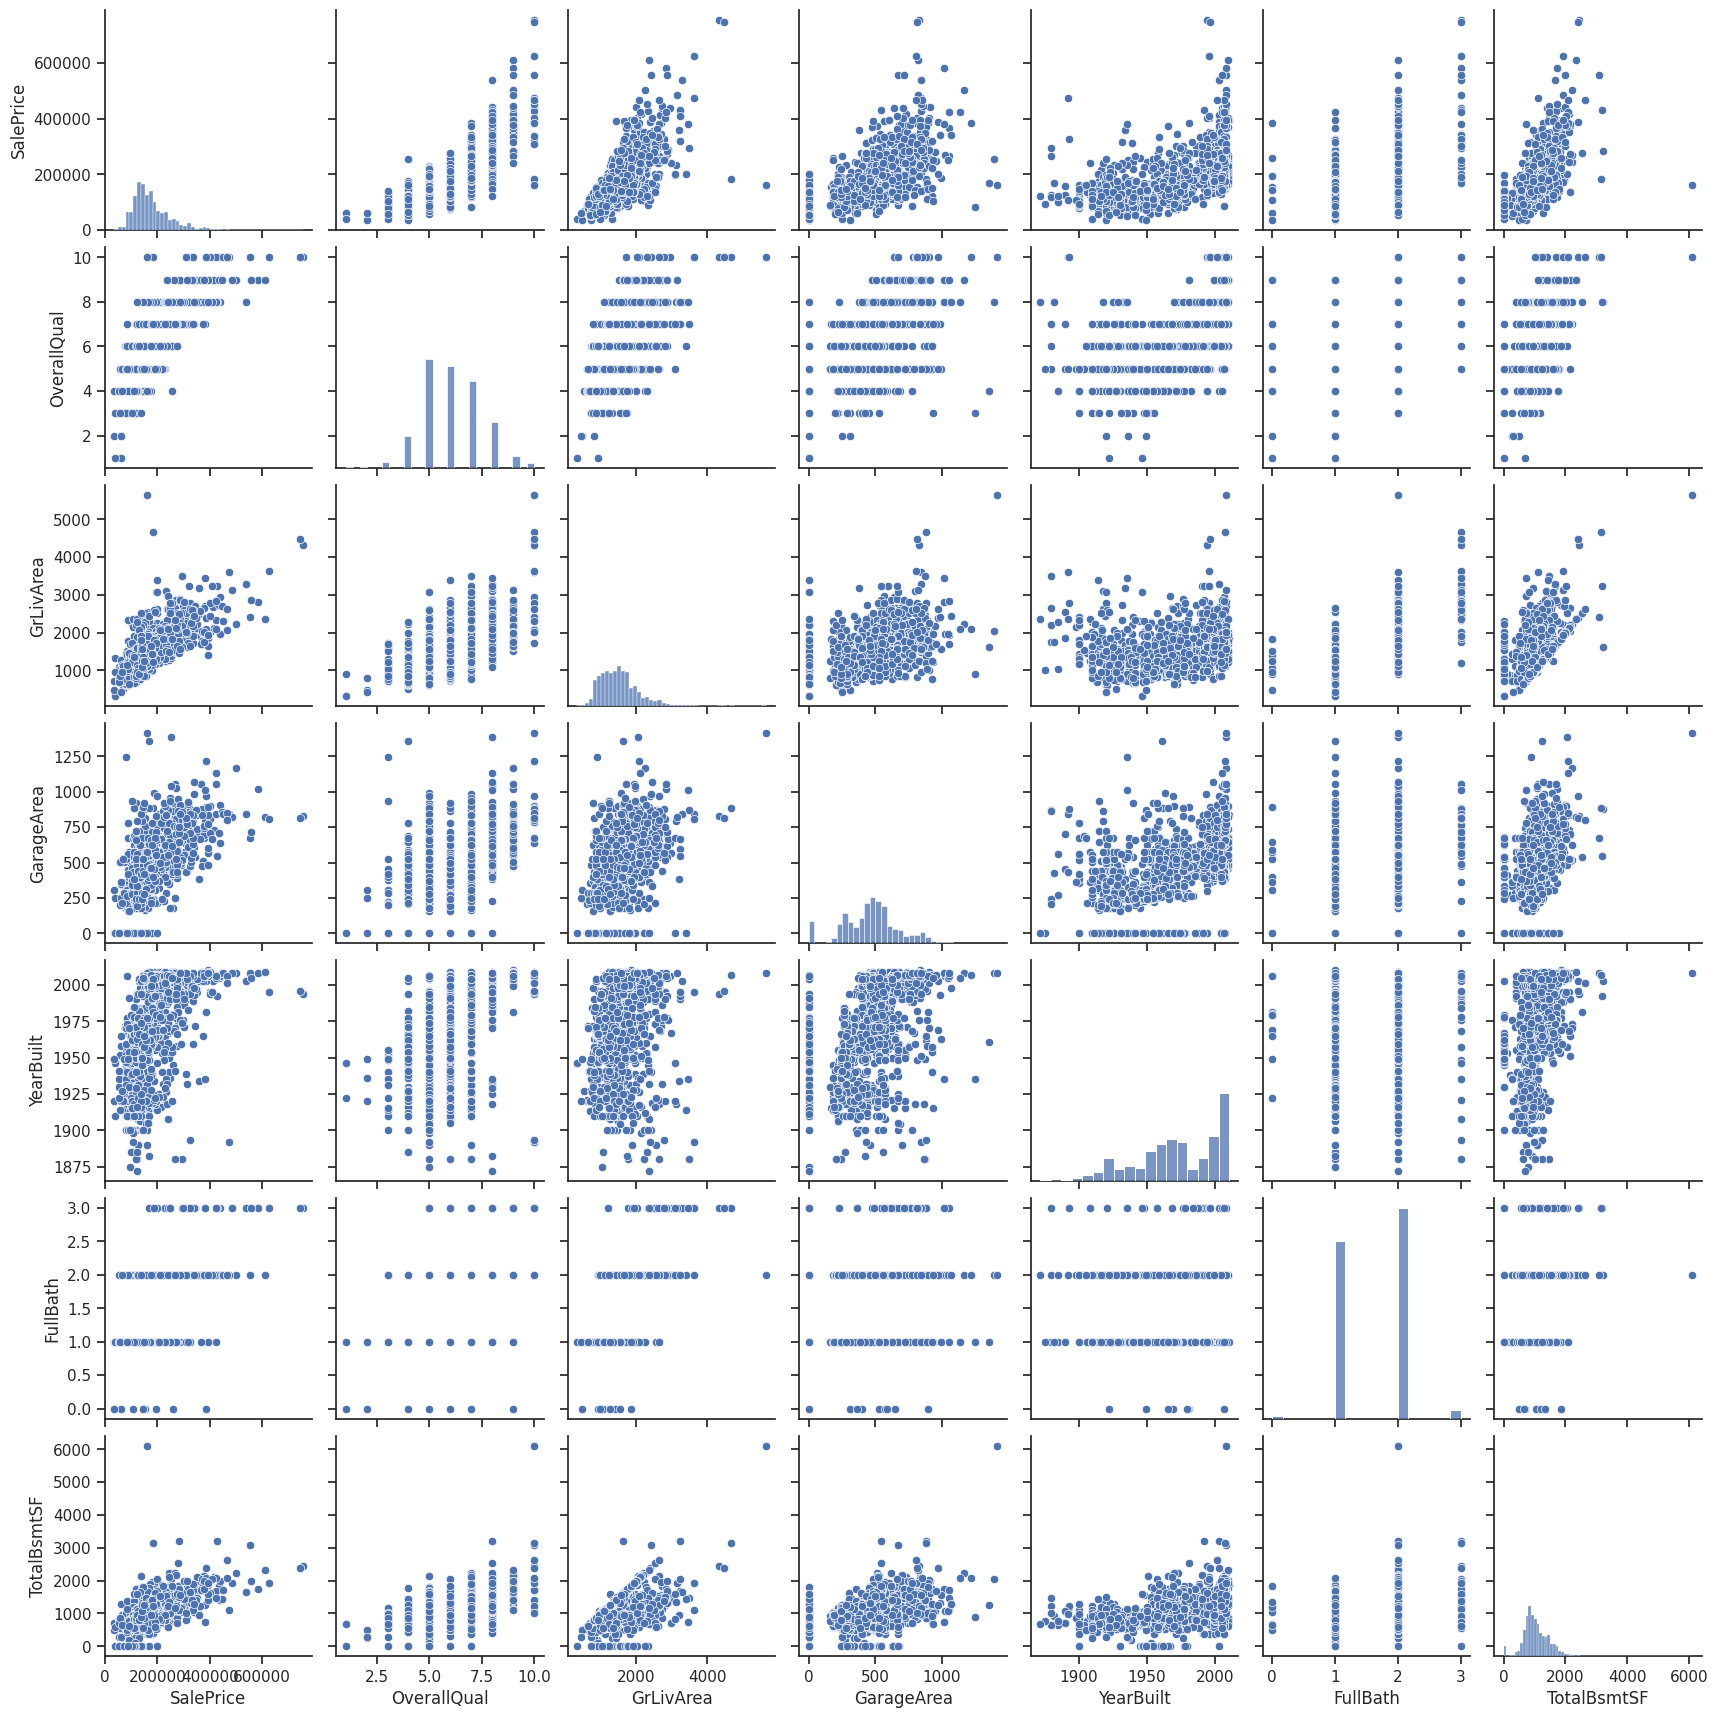

In [11]:
# look at columns most correlated with SalePrice
correlated_cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageArea', 'YearBuilt', 'FullBath', 'TotalBsmtSF']
sns.pairplot(train[correlated_cols])
plt.show()

## Normalization

`SalePrice` is right-skewed and can be roughly normalized with log scaling to produce a more normal regression target. Several area features are similarly skewed. Log scaling them linearizes their relationship with `log(SalePrice)` and reduces heteroscedasticity (the widening cone in the raw scatter plots above). This normalization of feature columns is mostly relevant for the linear Ridge regression model.

Area features like `TotalBsmtSF` and `GarageArea` contain zeros that represent no basement / no garage. These cannot be log scaled directly. To address this, each is split into a binary presence flag and a conditional log of the non-zero values.

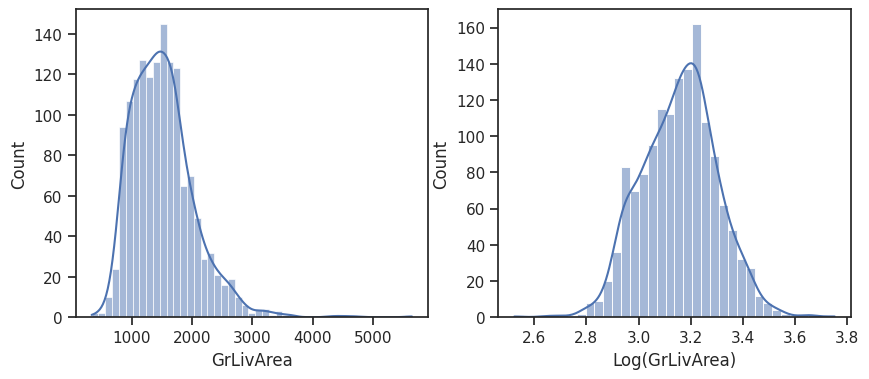

In [12]:
# GrLivArea is also skewed so might benefit from log scaling

fig, axs = plt.subplots(figsize=(10, 4), ncols=2)

sns.histplot(train['GrLivArea'], kde=True, ax=axs[0])

sns.histplot(np.log10(train['GrLivArea']), kde=True, ax=axs[1])
axs[1].set_xlabel('Log(GrLivArea)')

plt.show()

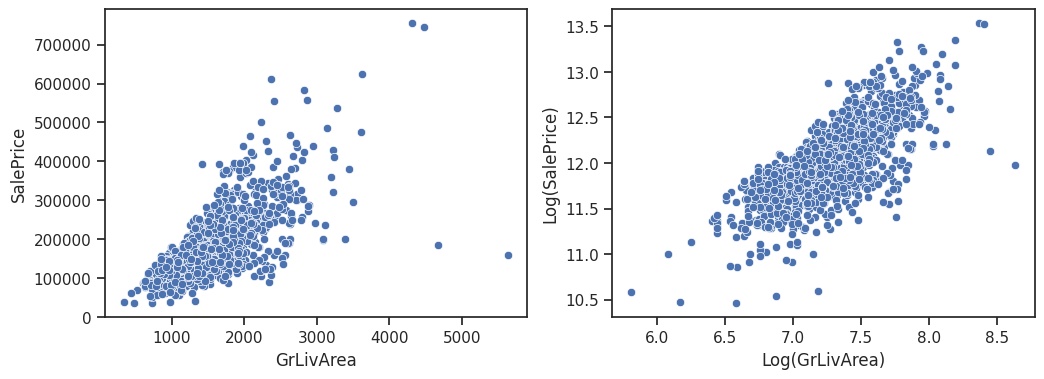

In [13]:
# log scaling SalePrice and GrLivArea results in a much more
# linear-looking relationship (was more conic before)
fig, axs = plt.subplots(figsize=(12, 4), ncols=2)

sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'], ax=axs[0])

sns.scatterplot(x=np.log(train['GrLivArea']), y=np.log(train['SalePrice']), ax=axs[1])
axs[1].set_xlabel('Log(GrLivArea)')
axs[1].set_ylabel('Log(SalePrice)')

plt.show()

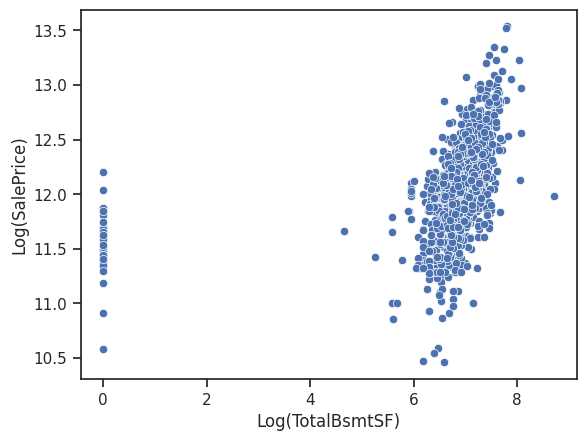

In [14]:
# can also make the same argument for TotalBsmtSF and GarageArea but these
# have 0s so can't log scale directly and have to add a flag so that
# the cluster of 0s doesn't skew linear regression
train['LogTotalBsmtSF'] = np.log1p(train['TotalBsmtSF']) # use log1p to add 1 and take log (negligible impact to large area values)
train['HasBasement']    = (~train['LogTotalBsmtSF'].eq(0))

sns.scatterplot(x=train['LogTotalBsmtSF'], y=np.log(train['SalePrice']))
plt.xlabel('Log(TotalBsmtSF)')
plt.ylabel('Log(SalePrice)')

plt.show()

### More in Depth Feature Normalization for Ridge
Columns that should be normalized are continuous numerical variables. Columns like GarageCars or OveralQual are counts / ratings so even though they are numeric it doesn't really make sense to log scale them. As a convention we can choose to set all continuous numeric variables as `float` dtypes and leave counts or ratings as `int` dtypes. This narrows down which columns should be investigated.

In [46]:
def qq_correlation(series):
    '''
    Pearson correlation coefficient between sample quantiles and
    theoretical normal quantiles. Normally distributed data will
    have a correlation coefficient close to 1
    '''
    (_, _), (_, _, corr_coef) = stats.probplot(series)

    return corr_coef


def plot_dist(data_series, label=None):
    '''
    Plot a histogram + a QQ prob plot for a
    given Series
    '''
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(data_series, kde=True, ax=axs[0])
    if label is not None:
        axs[0].set_xlabel(label)

    _ = stats.probplot(data_series, plot=axs[1])
    axs[1].set_title('')

    plt.show()


def qq_plot_matrix(df, columns):
    '''
    Plots a matrix of subplots showing QQ plots
    of a column in df to visualize normality

    Note: Ignores 0 values
    '''
    qq_corrs = pd.Series({col: qq_correlation(df[col]) for col in columns})
    qq_corrs = qq_corrs.sort_values()

    n_cols     = 3
    n_features = len(columns)

    fig, axes = plt.subplots(int(np.ceil(n_features / n_cols)), n_cols, figsize=(12, 10))

    for ax, col in zip(axes.flat, columns):
        stats.probplot(df[df[col] > 0][col].dropna(), plot=ax)
        ax.set_title(f'{col}  (corr_coef={qq_corrs[col]:.3f})', fontsize=9)
        ax.set_xlabel('')
        ax.set_ylabel('')

    plt.tight_layout()
    plt.show()

In [49]:
continuous_cols = ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
                   'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
                   'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
                   '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']

normalized_train                  = train.copy()
normalized_train[continuous_cols] = normalized_train[continuous_cols].astype(float)

# check which columns have 0s because we need to flag and log scale carefully
norm_stats = pd.DataFrame((normalized_train[continuous_cols].eq(0).sum() * 100. /
                           len(normalized_train)).astype(int), columns=['pct_0'])

# check the skew (right skew should be log scaled)
norm_stats['skew'] = normalized_train[continuous_cols].skew()

# calculate the qq pearson correlation to quantify column normality
# (ignore 0 values)
qq_corrs = pd.Series({col: qq_correlation(normalized_train[normalized_train[col]>0][col])
                      for col in normalized_train[continuous_cols]})

qq_corrs   = pd.DataFrame(qq_corrs, columns=['normal_corr'])
norm_stats = norm_stats.join(qq_corrs)

# same but after applying log scaling
log_qq_corrs = pd.Series({col: qq_correlation(np.log(normalized_train[normalized_train[col]>0][col]))
                          for col in normalized_train[continuous_cols]})

log_qq_corrs = pd.DataFrame(log_qq_corrs, columns=['log_normal_corr'])
norm_stats   = norm_stats.join(log_qq_corrs)

norm_stats.sort_values('normal_corr', ascending=False)

# note: some columns are mostly 0 so it is porbably
# not worth applying a log scaling to normalize these

,pct_0,skew,normal_corr,log_normal_corr
2ndFlrSF,56,0.813030,0.985428,0.979661
GarageArea,5,0.179981,0.978439,0.992796
EnclosedPorch,85,3.089872,0.975664,0.965678
BsmtUnfSF,8,0.920268,0.962713,0.981299
GrLivArea,0,1.366560,0.962634,0.997732
LowQualFinSF,98,9.011341,0.962076,0.923982
1stFlrSF,0,1.376757,0.961928,0.997592
ScreenPorch,92,4.122214,0.959571,0.983459
BsmtFinSF2,88,4.255261,0.959535,0.983936
PoolArea,99,14.828374,0.953940,0.968915


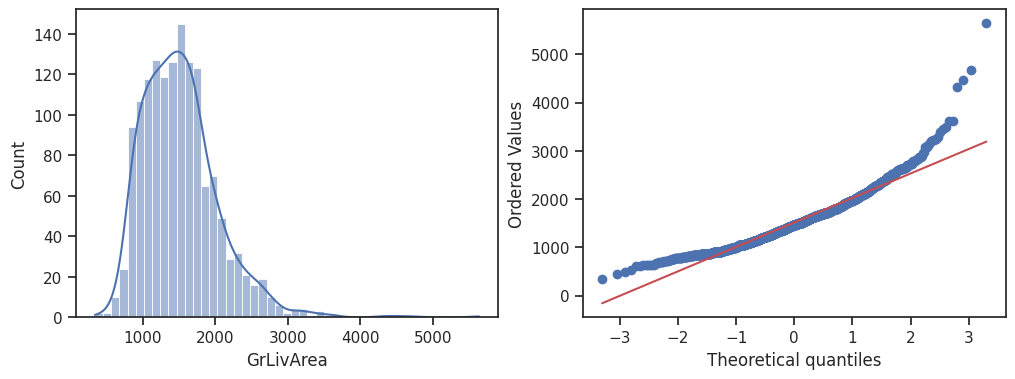

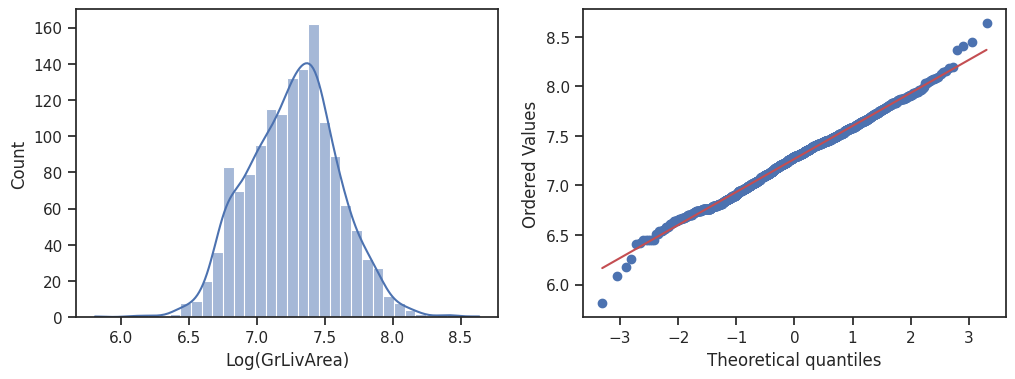

In [50]:
# visual test to see how log scaling improves normality
col_to_plot = 'GrLivArea'

plot_dist(train[col_to_plot])
plot_dist(np.log(train[col_to_plot]), f'Log({col_to_plot})')

Should aim to normalize (log scale) any columns that have $\mathrm{skew} \gt 0$, not too many zero values, and where applying the log scale increases the correlation with a normal distribution. For those columns that need to be normalized and contain zeros, we should add a HasX flag column so that the linear model can differentiate the zero values from the actual non-zero distribution.

In [51]:
cols_to_normalize = norm_stats[(norm_stats['skew'] > 0) &
                               (norm_stats['pct_0'] < 60) &
                               (norm_stats['log_normal_corr'] > norm_stats['normal_corr'])].index.to_list()
cols_to_normalize

['LotFrontage',
 'LotArea',
 'MasVnrArea',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 'GrLivArea',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF']

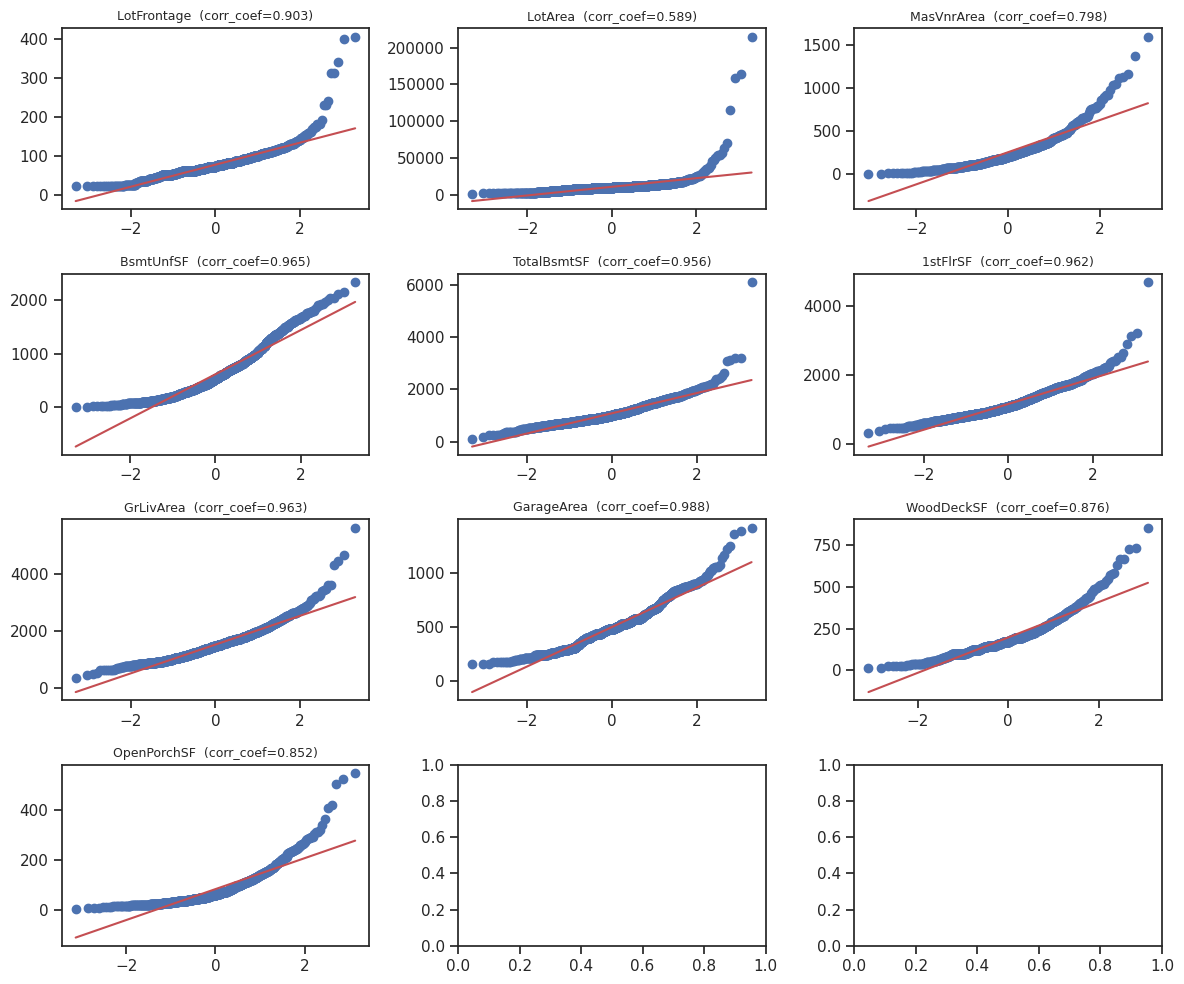

In [52]:
# plot these columns to visualize QQ before normalization
qq_plot_matrix(normalized_train, cols_to_normalize)

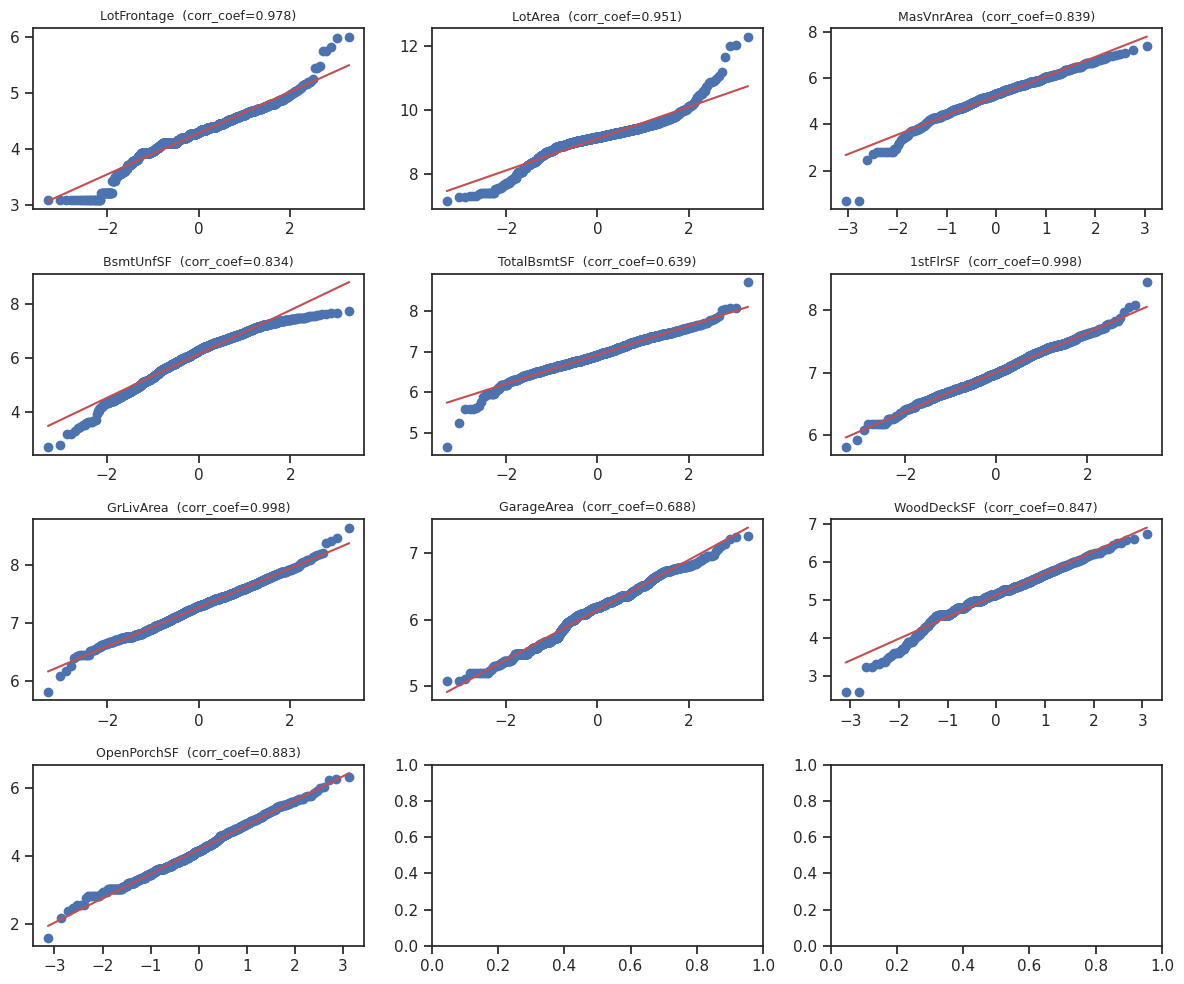

In [53]:
for col in cols_to_normalize:
    # just use log1p for all because it handles 0s and all values are >> 1
    normalized_train[col] = np.log1p(normalized_train[col])

    # if there are zeros then add 
    if normalized_train[col].eq(0).sum() > 0:
        normalized_train[f'Has_{col}'] = (~normalized_train[col].eq(0)).astype(float)

# plot these columns to visualize QQ AFTER normalization
qq_plot_matrix(normalized_train, cols_to_normalize)

## Outlier Identification

Fit a simple OLS reference model on log scaled features and inspect the standardised residuals. Rows where the actual price deviates far from what the model expects given the physical attributes are candidates for removal. Specifically some rows are observed where a good quality large house is being sold for quite cheap. It might be a good idea to remove these at least because they don't intuitively agree with the rest of the dataset

In [102]:
other_features     = ['OverallQual', 'YearBuilt', 'FullBath'] # don't need to transform
log_features       = ['GrLivArea'] # always > 0 so we can just log directly
split_log_features = ['TotalBsmtSF', 'GarageArea'] # these have clusters of 0 so need to flag and log with log1p

X_ref = train[log_features + split_log_features + other_features].copy()

for col in log_features:
    X_ref[col] = np.log(X_ref[col])

for col in split_log_features:
    X_ref[col]         = np.log1p(X_ref[col])
    X_ref[f'Has{col}'] = (~X_ref[col].eq(0)).astype(float)

y_ref = np.log(train['SalePrice'])

# standardize and fit
X_scaled  = StandardScaler().fit_transform(X_ref) # zscore the columns to have them all on a similar scale
ref_model = LinearRegression().fit(X_scaled, y_ref)

log_pred  = pd.Series(ref_model.predict(X_scaled), index=train.index)
residuals = y_ref - log_pred
std_resid = (residuals - residuals.mean()) / residuals.std()

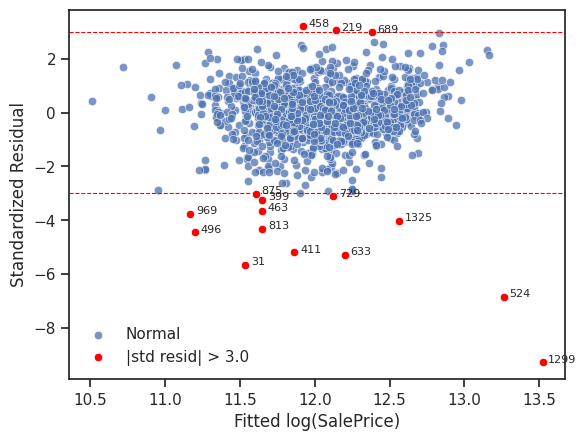

In [108]:
# residuals vs fitted
threshold    = 3.0 # std threshold to consider a point an outlier
outlier_mask = std_resid.abs() > threshold

outlier_mask_pos = std_resid > threshold
outlier_mask_neg = std_resid < -threshold

fig, ax = plt.subplots()

sns.scatterplot(x=log_pred[~outlier_mask], y=std_resid[~outlier_mask], alpha=0.75, label='Normal', ax=ax)
sns.scatterplot(x=log_pred[outlier_mask], y=std_resid[outlier_mask], color='red',
                zorder=5, label=f'|std resid| > {threshold}', ax=ax)

ax.axhline( threshold, color='red', linestyle='--', linewidth=0.8)
ax.axhline(-threshold, color='red', linestyle='--', linewidth=0.8)

for idx in train.index[outlier_mask]:
    ax.annotate(str(idx), xy=(log_pred[idx], std_resid[idx]),
                xytext=(4, 0), textcoords='offset points', fontsize=8)
    
ax.set_xlabel('Fitted log(SalePrice)')
ax.set_ylabel('Standardized Residual')
ax.legend()

plt.show()

In [109]:
# inspect flagged rows
context_cols = ['SalePrice', 'Neighborhood', 'SaleCondition', 'BldgType',
                'GrLivArea', 'TotalBsmtSF', 'GarageArea', 'OverallQual', 'YearBuilt']

outlier_ids = train.index[outlier_mask]
train.loc[outlier_ids, context_cols].assign(std_resid=std_resid[outlier_mask]).sort_values('std_resid')

,SalePrice,Neighborhood,SaleCondition,BldgType,GrLivArea,TotalBsmtSF,GarageArea,OverallQual,YearBuilt,std_resid
Id,,,,,,,,,,
1299,160000,Edwards,Partial,1Fam,5642,6110,1418,10,2008,-9.301611
524,184750,Edwards,Partial,1Fam,4676,3138,884,10,2007,-6.865192
31,40000,IDOTRR,Normal,1Fam,1317,649,250,4,1920,-5.660856
633,82500,NWAmes,Family,1Fam,1411,1386,544,7,1977,-5.302916
411,60000,Edwards,Abnorml,1Fam,1276,1276,350,5,1958,-5.203486
496,34900,IDOTRR,Abnorml,1Fam,720,720,0,4,1920,-4.451943
813,55993,IDOTRR,Alloca,1Fam,1044,540,504,5,1952,-4.318636
1325,147000,Somerst,Partial,1Fam,1795,1795,895,8,2006,-4.032613
969,37900,OldTown,Abnorml,1Fam,968,600,0,3,1910,-3.773520


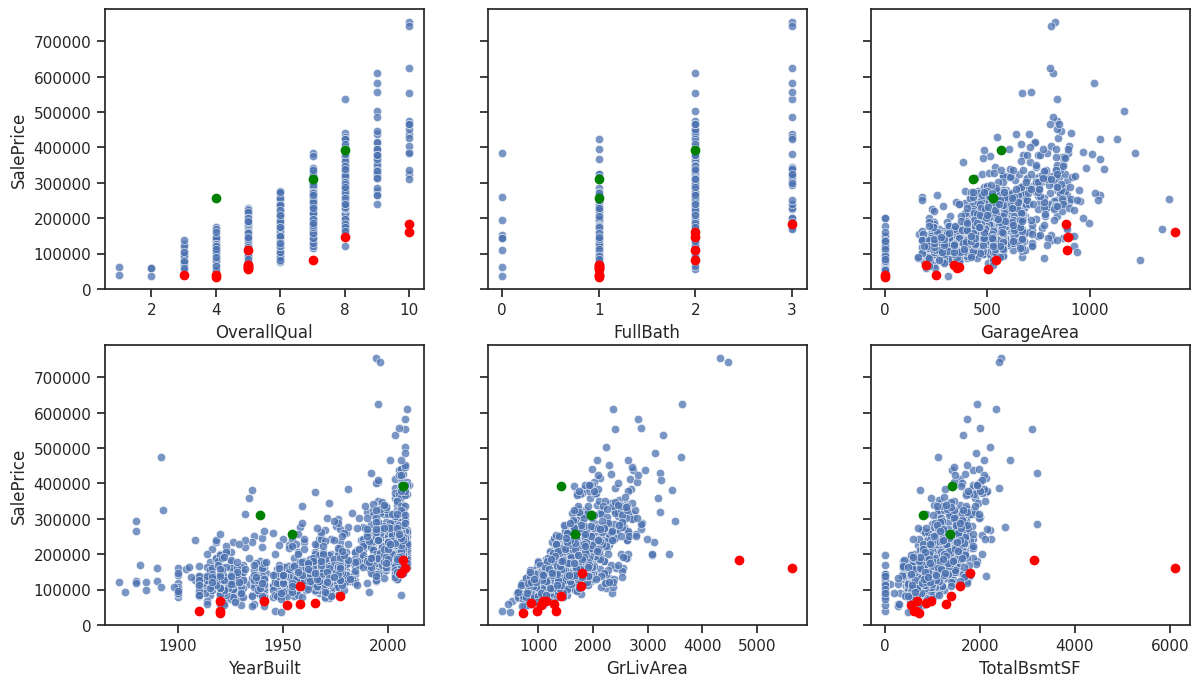

In [111]:
# plot the flagged outliers in all the distributions with SalePrice
# that were observed before

cols_to_plot = ['OverallQual', 'GrLivArea', 'GarageArea', 'YearBuilt', 'FullBath', 'TotalBsmtSF']

fig, axs = plt.subplots(2, 3, figsize=(14,8), sharey=True)

for i, col in enumerate(cols_to_plot):
    ax = axs[i%2, i%3]
    sns.scatterplot(data=train, x=col, y='SalePrice', alpha=0.75, ax=ax)

    # highlight the outliers (indicate positive and negative)
    outlier_ids = train.index[outlier_mask_pos]
    ax.scatter(train.loc[outlier_ids, col], train.loc[outlier_ids, 'SalePrice'],
               color='green', zorder=5, label=f'Outlier')
    
    outlier_ids = train.index[outlier_mask_neg]
    ax.scatter(train.loc[outlier_ids, col], train.loc[outlier_ids, 'SalePrice'],
               color='red', zorder=5, label=f'Outlier')

    ax.set_xlabel(col)
    if i%3 == 0:
        ax.set_ylabel('SalePrice')

plt.show()